Expected Threat (xT) Zone Distribution

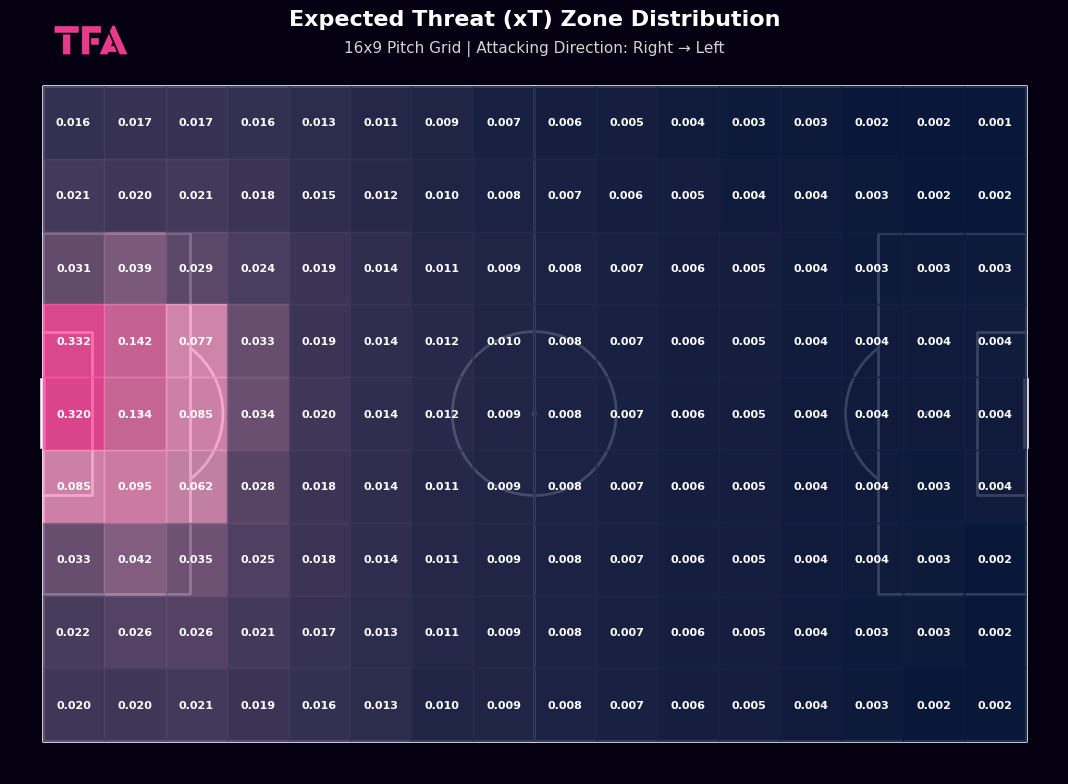

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from mplsoccer import Pitch
from matplotlib.colors import LinearSegmentedColormap, Normalize
from PIL import Image
import os

cols = 16
rows = 9

xT_grid = np.array([
    [0.001,0.002,0.002,0.003,0.003,0.004,0.005,0.006,0.007,0.009,0.011,0.013,0.016,0.017,0.017,0.016],
    [0.002,0.002,0.003,0.004,0.004,0.005,0.006,0.007,0.008,0.010,0.012,0.015,0.018,0.021,0.020,0.021],
    [0.003,0.003,0.003,0.004,0.005,0.006,0.007,0.008,0.009,0.011,0.014,0.019,0.024,0.029,0.039,0.031],
    [0.004,0.004,0.004,0.004,0.005,0.006,0.007,0.008,0.010,0.012,0.014,0.019,0.033,0.077,0.142,0.332],
    [0.004,0.004,0.004,0.004,0.005,0.006,0.007,0.008,0.009,0.012,0.014,0.020,0.034,0.085,0.134,0.320],
    [0.004,0.003,0.004,0.004,0.005,0.006,0.007,0.008,0.009,0.011,0.014,0.018,0.028,0.062,0.095,0.085],
    [0.002,0.003,0.004,0.004,0.005,0.006,0.007,0.008,0.009,0.011,0.014,0.018,0.025,0.035,0.042,0.033],
    [0.002,0.003,0.003,0.004,0.005,0.006,0.007,0.008,0.009,0.011,0.013,0.017,0.021,0.026,0.026,0.022],
    [0.002,0.002,0.003,0.004,0.005,0.006,0.007,0.008,0.009,0.010,0.013,0.016,0.019,0.021,0.020,0.020]
])

xT_grid = np.fliplr(xT_grid)

pitch = Pitch(pitch_type='statsbomb', pitch_color='#050011', line_color='white')
fig, ax = pitch.draw(figsize=(12, 8))
fig.patch.set_facecolor("#050011")

cmap = LinearSegmentedColormap.from_list("xt_map", ["#0A1C3F", "#F5A3C9E0", "#E778ACE1", "#F05DA2E1", "#FF3C97DF", "#FF55A4DF"])
norm = Normalize(vmin=xT_grid.min(), vmax=xT_grid.max())

cell_width = 120 / cols
cell_height = 80 / rows

for i in range(rows):
    for j in range(cols):
        x = j * cell_width
        y = i * cell_height
        value = xT_grid[i, j]
        color = cmap(norm(value))
        rect = plt.Rectangle((x, y), cell_width, cell_height, color=color, alpha=0.85)
        ax.add_patch(rect)
        ax.text(x + cell_width/2, y + cell_height/2, f"{value:.3f}",
                ha='center', va='center', color='white', fontsize=8, weight='bold')

plt.suptitle("Expected Threat (xT) Zone Distribution",
             color='white', fontsize=16, weight='bold', y=0.975)

plt.title("16x9 Pitch Grid | Attacking Direction: Right → Left",
          color='lightgrey', fontsize=11, y=0.9899)

tfa_logo_path = r"D:\Work\Data Analysis TFA\06 How Ancelotti Could Reshape Brazil\logos\TFA.png"
if os.path.exists(tfa_logo_path):
    tfa_img = Image.open(tfa_logo_path).convert("RGBA")
    tfa_img = tfa_img.resize((int(tfa_img.width * 0.24), int(tfa_img.height * 0.24)))
    fig.figimage(tfa_img, xo=43, yo=696, alpha=0.95, zorder=10)

plt.tight_layout()
plt.show()

Measuring Territorial Progression Value And Final Third Threat Creation Across All 20  - Premier League 2025-2026

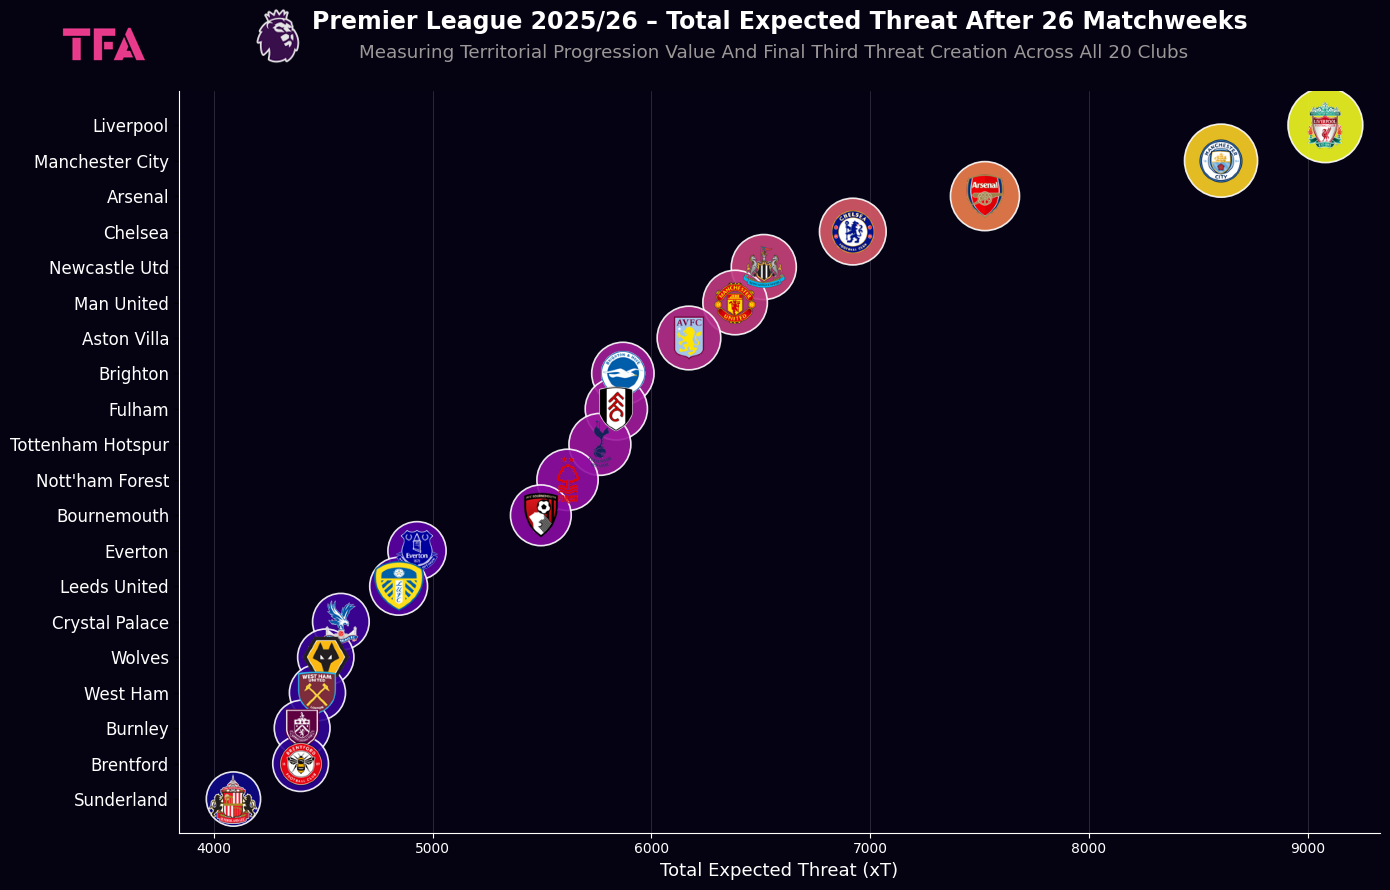

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from PIL import Image
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

data = {
    "Club": [
        "Liverpool","Manchester City","Arsenal","Chelsea","Newcastle Utd",
        "Man United","Aston Villa","Brighton","Fulham",
        "Tottenham Hotspur","Nott'ham Forest","Bournemouth","Everton",
        "Leeds United","Crystal Palace","Wolves","West Ham",
        "Burnley","Brentford","Sunderland"
    ],
    "xT": [
        9081,8604,7525,6921,6514,6383,6172,5870,5840,5765,
        5617,5495,4929,4845,4581,4512,4474,4404,4397,4090
    ]
}

df = pd.DataFrame(data)
df = df.sort_values("xT", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 9))
ax.set_facecolor("#050213")
fig.patch.set_facecolor("#050211")

y = np.arange(len(df))
x = df["xT"].values

norm = plt.Normalize(df["xT"].min(), df["xT"].max())
colors = plt.cm.plasma(norm(x))
sizes = (x / max(x)) * 2500 + 400

ax.scatter(x, y, s=sizes, c=colors, alpha=0.9, edgecolors='white', linewidth=1.2, zorder=3)

ax.set_yticks(y)
ax.set_yticklabels(df["Club"], fontsize=12, color='white')

ax.set_xlabel('Total Expected Threat (xT)', fontsize=13, color='white')

ax.set_title(
    "Premier League 2025/26 – Total Expected Threat After 26 Matchweeks",
    fontsize=17, color='white', weight='bold', pad=45
)

fig.text(
    0.556, 0.93,
    "Measuring Territorial Progression Value And Final Third Threat Creation Across All 20 Clubs",
    ha='center', fontsize=13.2, color="#9C9898"
)

ax.invert_yaxis()

ax.tick_params(axis='x', colors='white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')

ax.grid(True, axis='x', color='white', linestyle='-', linewidth=0.4, alpha=0.25)

logos_path = r"D:\Work\Data Analysis TFA\04 Vertical Progressions & Transitional Threat Analysis\logos"

for i, club in enumerate(df['Club']):
    logo_path = os.path.join(logos_path, f"{club}.png")
    if os.path.exists(logo_path):
        logo_img = Image.open(logo_path).convert("RGBA")
        logo_img = logo_img.resize((60, 60))
        imagebox = OffsetImage(logo_img, zoom=0.6)
        ab = AnnotationBbox(imagebox, (x[i], y[i]), frameon=False, box_alignment=(0.5, 0.5), xycoords='data', pad=0)
        ax.add_artist(ab)

tfa_logo_path = r"D:\Work\Data Analysis TFA\06 How Ancelotti Could Reshape Brazil\logos\TFA.png"
if os.path.exists(tfa_logo_path):
    tfa_img = Image.open(tfa_logo_path).convert("RGBA")
    tfa_img = tfa_img.resize((int(tfa_img.width * 0.27), int(tfa_img.height * 0.27)))
    fig.figimage(tfa_img, xo=50, yo=792, alpha=0.95, zorder=10)

epl_logo_path = r"D:\Work\Data Analysis TFA\34 Man City vs Liverpool preview\Main logos\EPL Logo.png"
if os.path.exists(epl_logo_path):
    epl_img = Image.open(epl_logo_path).convert("RGBA")
    epl_img = epl_img.resize((int(epl_img.width * 0.92), int(epl_img.height * 0.92)))
    fig.figimage(epl_img, xo=249, yo=825, alpha=0.9, zorder=10)

plt.tight_layout()
plt.show()

Premier League 2025-2026 – Top 20 Players Ranked By xT Rating After Matchweek 26

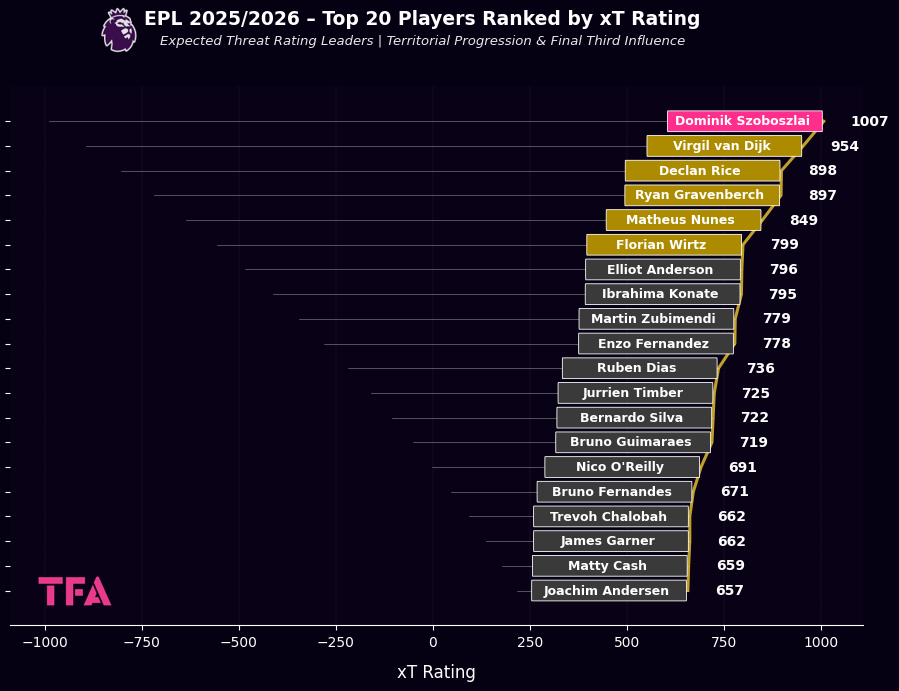

In [137]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib import colors as mcolors
import os

data = {
    "Player": [
        "Dominik Szoboszlai","Virgil van Dijk","Declan Rice","Ryan Gravenberch",
        "Matheus Nunes","Florian Wirtz","Elliot Anderson","Ibrahima Konate",
        "Martin Zubimendi","Enzo Fernandez","Ruben Dias","Jurrien Timber",
        "Bernardo Silva","Bruno Guimaraes","Nico O'Reilly","Bruno Fernandes",
        "Trevoh Chalobah","James Garner","Matty Cash","Joachim Andersen"
    ],
    "Club": [
        "Liverpool","Liverpool","Arsenal","Liverpool","Manchester City",
        "Liverpool","Nottingham Forest","Liverpool","Arsenal","Chelsea",
        "Manchester City","Arsenal","Manchester City","Newcastle United",
        "Manchester City","Manchester United","Chelsea","Everton",
        "Aston Villa","Fulham"
    ],
    "xT Rating": [
        1007,954,898,897,849,799,796,795,779,778,736,725,722,719,691,671,662,662,659,657
    ]
}

df = pd.DataFrame(data).sort_values("xT Rating")

fig, ax = plt.subplots(figsize=(11,7))
fig.patch.set_facecolor("#060013")
ax.set_facecolor("#090116")

ax.plot(df["xT Rating"], range(len(df)),
        color="#FFD733", linewidth=2.2, alpha=0.75, zorder=2)

for i, row in df.iterrows():
    y = df.index.get_loc(i)

    if row["xT Rating"] == df["xT Rating"].max():
        box_color = "#FF2D8B"
    elif row["xT Rating"] >= df["xT Rating"].nlargest(6).min():
        box_color = "#AD8B00"
    else:
        box_color = "#3A3A3A"

    ax.add_patch(
        FancyBboxPatch(
            (row["xT Rating"] - 402, y - 0.12),
            398, 0.24,
            boxstyle="round,pad=0.3",
            linewidth=0.6,
            edgecolor="white",
            facecolor=box_color,
            zorder=3
        )
    )

    ax.text(
        row["xT Rating"] - 210, y,
        f'{row["Player"]}',
        ha="center", va="center",
        fontsize=9,
        color="white",
        weight="bold",
        zorder=4
    )

    ax.text(
        row["xT Rating"] + 70, y,
        f'{row["xT Rating"]}',
        ha="left", va="center",
        fontsize=10,
        color="white",
        weight="bold"
    )

    ax.plot(
        [row["xT Rating"], ax.get_xlim()[0]],
        [y, y],
        color="white", linewidth=0.4, alpha=0.55, zorder=1
    )

ax.set_yticks(range(len(df)))
ax.set_yticklabels([""] * len(df))
ax.set_xlabel("xT Rating", color="white", fontsize=12, labelpad=10)
ax.tick_params(colors="white", labelsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("white")
ax.grid(True, axis="x", color="white", linewidth=0.25, alpha=0.2, linestyle="--")

plt.suptitle(
    "EPL 2025/2026 – Top 20 Players Ranked by xT Rating",
    color="white", fontsize=13.5, weight="bold", x=0.5, y=0.99
)

plt.text(
    0.5, 0.945,
    "Expected Threat Rating Leaders | Territorial Progression & Final Third Influence",
    ha="center", va="center", transform=fig.transFigure,
    color="#E8E8E8", fontsize=9.5, style="italic"
)

tfa_logo_path = r"D:\Work\Data Analysis TFA\06 How Ancelotti Could Reshape Brazil\logos\TFA.png"
if os.path.exists(tfa_logo_path):
    tfa_img = Image.open(tfa_logo_path).convert("RGBA")
    tfa_img = tfa_img.resize((int(tfa_img.width * 0.24), int(tfa_img.height * 0.24)))
    fig.figimage(tfa_img, xo=27, yo=52, alpha=0.95, zorder=10)

epl_logo_path = r"D:\Work\Data Analysis TFA\34 Man City vs Liverpool preview\Main logos\EPL Logo.png"
if os.path.exists(epl_logo_path):
    epl_img = Image.open(epl_logo_path).convert("RGBA")
    epl_img = epl_img.resize((int(epl_img.width * 0.75), int(epl_img.height * 0.75)))
    fig.figimage(epl_img, xo=95, yo=637, alpha=0.9, zorder=10)

plt.show()

Top EPL 20 Players Ranked By xT And XG Rating

C:\Users\muspo\AppData\Local\Temp\ipykernel_9932\2282960415.py:42: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(top5["xT Rating"], top5["xG"],
C:\Users\muspo\AppData\Local\Temp\ipykernel_9932\2282960415.py:45: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(others["xT Rating"], others["xG"],


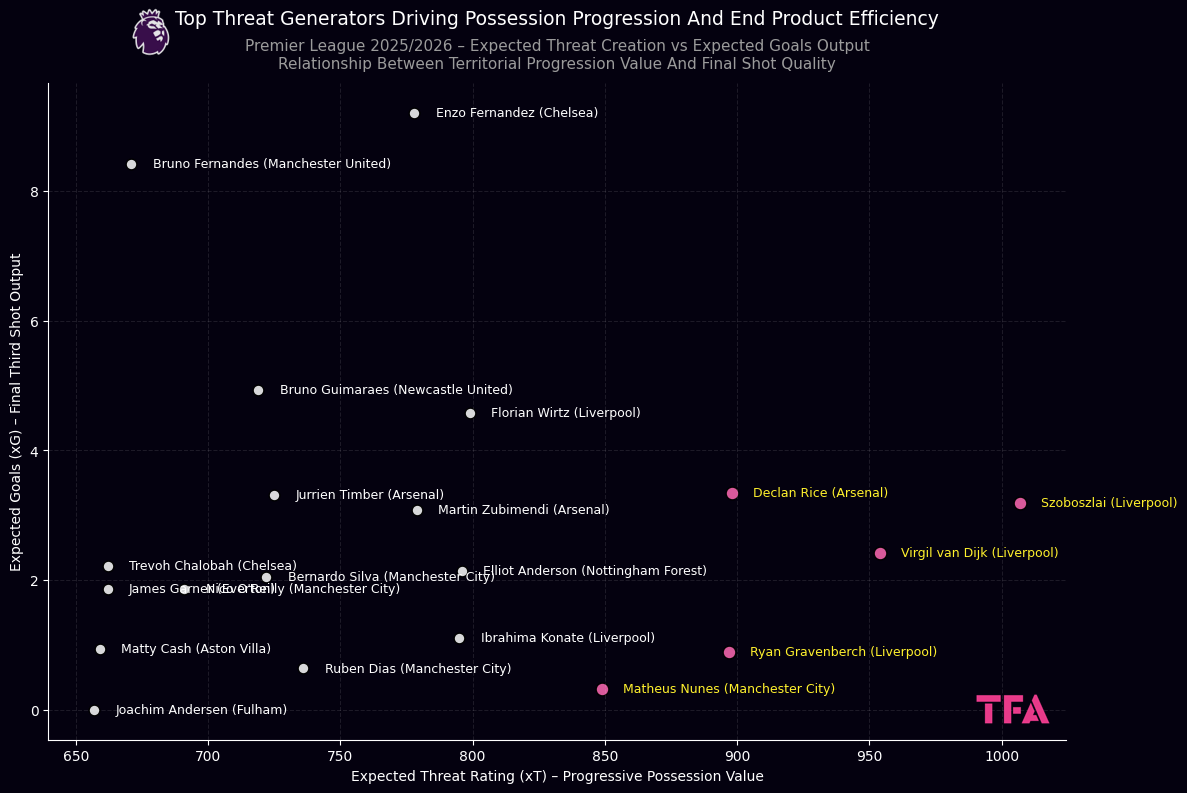

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib import colors as mcolors
import os

data = {
    "Player": [
        "Szoboszlai","Virgil van Dijk","Declan Rice","Ryan Gravenberch",
        "Matheus Nunes","Florian Wirtz","Elliot Anderson","Ibrahima Konate",
        "Martin Zubimendi","Enzo Fernandez","Ruben Dias","Jurrien Timber",
        "Bernardo Silva","Bruno Guimaraes","Nico O'Reilly","Bruno Fernandes",
        "Trevoh Chalobah","James Garner","Matty Cash","Joachim Andersen"
    ],
    "Club": [
        "Liverpool","Liverpool","Arsenal","Liverpool","Manchester City",
        "Liverpool","Nottingham Forest","Liverpool","Arsenal","Chelsea",
        "Manchester City","Arsenal","Manchester City","Newcastle United",
        "Manchester City","Manchester United","Chelsea","Everton",
        "Aston Villa","Fulham"
    ],
    "xT Rating": [
        1007,954,898,897,849,799,796,795,779,778,736,725,722,719,691,671,662,662,659,657
    ],
    "xG": [
        3.19,2.42,3.34,0.9,0.32,4.58,2.14,1.11,3.08,9.2,0.64,3.31,2.05,4.94,1.86,8.42,
        2.22,1.87,0.94,0
    ]
}

df = pd.DataFrame(data)
df = df.sort_values(by="xT Rating", ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
ax.set_facecolor("#04010F")
fig.patch.set_facecolor("#04010F")

top5 = df.head(5)
others = df.iloc[5:]

ax.scatter(top5["xT Rating"], top5["xG"],
           c=mcolors.to_rgba("#FF69B4", alpha=0.85),
           s=85, edgecolors="black")
ax.scatter(others["xT Rating"], others["xG"],
           c=mcolors.to_rgba("white", alpha=0.85),
           s=60, edgecolors="black")

for _, row in df.iterrows():
    color = "#FFF12D" if row.name in top5.index else "white"
    ax.text(row["xT Rating"] + 8, row["xG"],
            f'{row["Player"]} ({row["Club"]})',
            fontsize=9, ha="left", va="center", color=color)

ax.set_title(
    "Premier League 2025/2026 – Expected Threat Creation vs Expected Goals Output\n"
    "Relationship Between Territorial Progression Value And Final Shot Quality",
    color="#9B9B9B", fontsize=11, pad=11
)

ax.text(
    0.5, 1.09,
    "Top Threat Generators Driving Possession Progression And End Product Efficiency",
    transform=ax.transAxes,
    ha="center",
    fontsize=13.5,
    color="#FFFFFF"
)

ax.set_xlabel("Expected Threat Rating (xT) – Progressive Possession Value", color="white")
ax.set_ylabel("Expected Goals (xG) – Final Third Shot Output", color="white")

ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_color("white")
ax.spines["left"].set_color("white")
ax.grid(color="white", linestyle="--", alpha=0.1)

tfa_logo_path = r"D:\Work\Data Analysis TFA\06 How Ancelotti Could Reshape Brazil\logos\TFA.png"
if os.path.exists(tfa_logo_path):
    tfa_img = Image.open(tfa_logo_path).convert("RGBA")
    tfa_img = tfa_img.resize((int(tfa_img.width * 0.24), int(tfa_img.height * 0.24)))
    fig.figimage(tfa_img, xo=965, yo=36, alpha=0.95, zorder=10)

epl_logo_path = r"D:\Work\Data Analysis TFA\34 Man City vs Liverpool preview\Main logos\EPL Logo.png"
if os.path.exists(epl_logo_path):
    epl_img = Image.open(epl_logo_path).convert("RGBA")
    epl_img = epl_img.resize((int(epl_img.width * 0.79), int(epl_img.height * 0.79)))
    fig.figimage(epl_img, xo=126, yo=736, alpha=0.9, zorder=10)

plt.tight_layout()
plt.show()

Dominik Szoboszlai Chance Creation & xT Zone Impact - Premier League 2025-2026

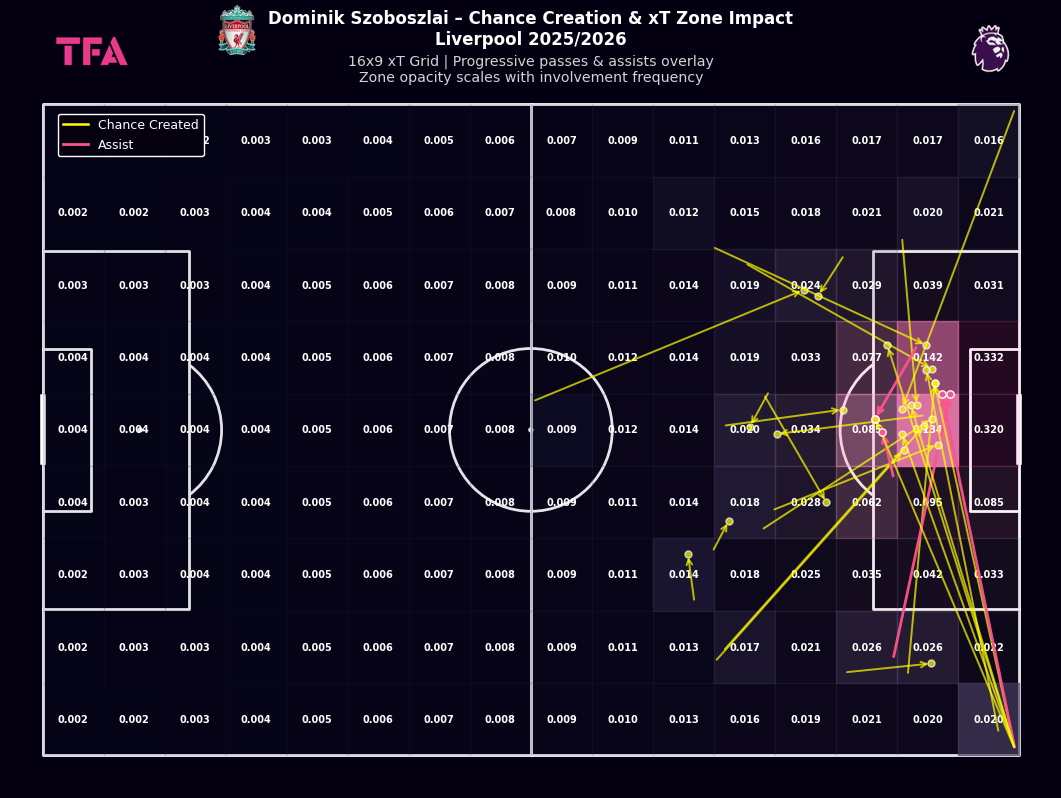

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import Pitch
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.lines import Line2D
from PIL import Image
import os

cols = 16
rows = 9

xT_grid = np.array([
    [0.001,0.002,0.002,0.003,0.003,0.004,0.005,0.006,0.007,0.009,0.011,0.013,0.016,0.017,0.017,0.016],
    [0.002,0.002,0.003,0.004,0.004,0.005,0.006,0.007,0.008,0.010,0.012,0.015,0.018,0.021,0.020,0.021],
    [0.003,0.003,0.003,0.004,0.005,0.006,0.007,0.008,0.009,0.011,0.014,0.019,0.024,0.029,0.039,0.031],
    [0.004,0.004,0.004,0.004,0.005,0.006,0.007,0.008,0.010,0.012,0.014,0.019,0.033,0.077,0.142,0.332],
    [0.004,0.004,0.004,0.004,0.005,0.006,0.007,0.008,0.009,0.012,0.014,0.020,0.034,0.085,0.134,0.320],
    [0.004,0.003,0.004,0.004,0.005,0.006,0.007,0.008,0.009,0.011,0.014,0.018,0.028,0.062,0.095,0.085],
    [0.002,0.003,0.004,0.004,0.005,0.006,0.007,0.008,0.009,0.011,0.014,0.018,0.025,0.035,0.042,0.033],
    [0.002,0.003,0.003,0.004,0.005,0.006,0.007,0.008,0.009,0.011,0.013,0.017,0.021,0.026,0.026,0.022],
    [0.002,0.002,0.003,0.004,0.005,0.006,0.007,0.008,0.009,0.010,0.013,0.016,0.019,0.021,0.020,0.020]
])

data = [
[98.5,69.8,109.2,68.7,0],
[80.1,61.2,79.3,55.3,0],
[82.3,55,84.3,51.2,0],
[89.3,35.2,86.9,39.6,0],
[88.6,35.6,96.3,48.9,0],
[83.6,39.5,98.3,37.5,0],
[60.2,36.5,93.5,22.8,0],
[98.5,18.5,95.3,23.5,0],
[82.6,68.5,105.8,42.5,0],
[83.6,67.2,108.3,39.5,0],
[88.3,52.3,109.3,38.6,0],
[89.6,49.9,110,41.8,0],
[82.3,17.5,108.6,29.6,0],
[86.3,19.5,109.3,32.5,0],
[108.5,38.2,90.2,40.5,0],
[106.3,70.2,109.6,34.2,0],
[104.5,68.2,111.5,35.6,1],
[105.6,16.3,107.4,37,0],
[104.6,46,103.2,40.2,1],
[107.5,29.6,102.3,38.6,1],
[119.5,79.3,105.6,40.5,0],
[119.5,79.3,109.6,34.2,0],
[119.5,79.3,110.5,35.6,1],
[119.5,79.3,106.7,37,0],
[119.5,79.3,103.8,29.6,0],
[119.5,79.3,102.3,38.6,0],
[117.5,77.3,108.6,32.6,0],
[119.5,0.5,105.6,37.4,0]
]

df = pd.DataFrame(data, columns=["x_start","y_start","x_end","y_end","assist"])

pitch = Pitch(pitch_type='statsbomb', pitch_color='#050011', line_color='white')
fig, ax = pitch.draw(figsize=(12,8))
fig.patch.set_facecolor('#050011')

cmap = LinearSegmentedColormap.from_list("xt_map",
["#0A1C3F","#F5A3C9E0","#E778ACE1","#F05DA2E1","#FF3C97DF","#FF55A4DF"])
norm = Normalize(vmin=xT_grid.min(), vmax=xT_grid.max())

cell_w = 120 / cols
cell_h = 80 / rows

cell_counts = np.zeros((rows, cols))

for _, row in df.iterrows():
    start_col = int(row['x_start'] // cell_w)
    start_row = int(row['y_start'] // cell_h)
    end_col = int(row['x_end'] // cell_w)
    end_row = int(row['y_end'] // cell_h)

    if 0 <= start_row < rows and 0 <= start_col < cols:
        cell_counts[start_row, start_col] += 1
    if 0 <= end_row < rows and 0 <= end_col < cols:
        cell_counts[end_row, end_col] += 1

max_count = cell_counts.max()

for i in range(rows):
    for j in range(cols):
        x = j * cell_w
        y = i * cell_h
        val = xT_grid[i, j]
        color = cmap(norm(val))

        if cell_counts[i, j] > 0:
            alpha_val = 0.2 + (cell_counts[i, j] / max_count) * 0.75
        else:
            alpha_val = 0.12

        rect = plt.Rectangle((x, y), cell_w, cell_h,
                             color=color, alpha=alpha_val)
        ax.add_patch(rect)

        ax.text(x + cell_w/2, y + cell_h/2,
                f"{val:.3f}",
                ha='center', va='center',
                color='white', fontsize=7, weight='bold')

for _, row in df.iterrows():
    if row['assist'] == 1:
        ax.annotate('', xy=(row['x_end'], row['y_end']),
                    xytext=(row['x_start'], row['y_start']),
                    arrowprops=dict(arrowstyle='->',
                                    color='#FF538C',
                                    lw=2,
                                    alpha=0.95))
        ax.scatter(row['x_end'], row['y_end'],
                   s=28,
                   color='#FF538C',
                   edgecolor='white',
                   zorder=6)
    else:
        ax.annotate('', xy=(row['x_end'], row['y_end']),
                    xytext=(row['x_start'], row['y_start']),
                    arrowprops=dict(arrowstyle='->',
                                    color='yellow',
                                    lw=1.4,
                                    alpha=0.7))
        ax.scatter(row['x_end'], row['y_end'],
                   s=25,
                   facecolors='yellow',
                   edgecolors='white',
                   alpha=0.7,
                   zorder=6)

plt.suptitle("Dominik Szoboszlai – Chance Creation & xT Zone Impact\nLiverpool 2025/2026",
             color='white', fontsize=12, weight='bold', y=0.992)

fig.text(0.5, 0.902,
         "16x9 xT Grid | Progressive passes & assists overlay\nZone opacity scales with involvement frequency",
         ha='center', color='lightgrey', fontsize=10.2)

legend_elements = [
    Line2D([0],[0],color='yellow',lw=1.8,label='Chance Created'),
    Line2D([0],[0],color='#FF538C',lw=2,label='Assist'),
]

legend = ax.legend(handles=legend_elements,
                   loc='upper left',
                   fontsize=9,
                   frameon=True,
                   labelcolor='white',
                   bbox_to_anchor=(0.04,0.95))

frame = legend.get_frame()
frame.set_facecolor("#060111")
frame.set_edgecolor("white")
frame.set_alpha(1)

tfa_logo_path = r"D:\Work\Data Analysis TFA\06 How Ancelotti Could Reshape Brazil\logos\TFA.png"
if os.path.exists(tfa_logo_path):
    img = Image.open(tfa_logo_path).convert("RGBA")
    img = img.resize((int(img.width*0.235), int(img.height*0.235)))
    fig.figimage(img, xo=45, yo=700, alpha=0.95, zorder=10)

liv_logo_path = r"D:\Work\Data Analysis TFA\04 Vertical Progressions & Transitional Threat Analysis\logos\Liverpool.png"
if os.path.exists(liv_logo_path):
    img = Image.open(liv_logo_path).convert("RGBA")
    img = img.resize((int(img.width*0.18), int(img.height*0.18)))
    fig.figimage(img, xo=210, yo=741, alpha=0.95, zorder=10)

epl_logo_path = r"D:\Work\Data Analysis TFA\34 Man City vs Liverpool preview\Main logos\EPL Logo.png"
if os.path.exists(epl_logo_path):
    img = Image.open(epl_logo_path).convert("RGBA")
    img = img.resize((int(img.width*0.8), int(img.height*0.8)))
    fig.figimage(img, xo=965, yo=724, alpha=0.95, zorder=10)

plt.tight_layout()
plt.show()

Bruno Fernandes Chance Creation And xT Zone Impact With Manchester United 2025-2026

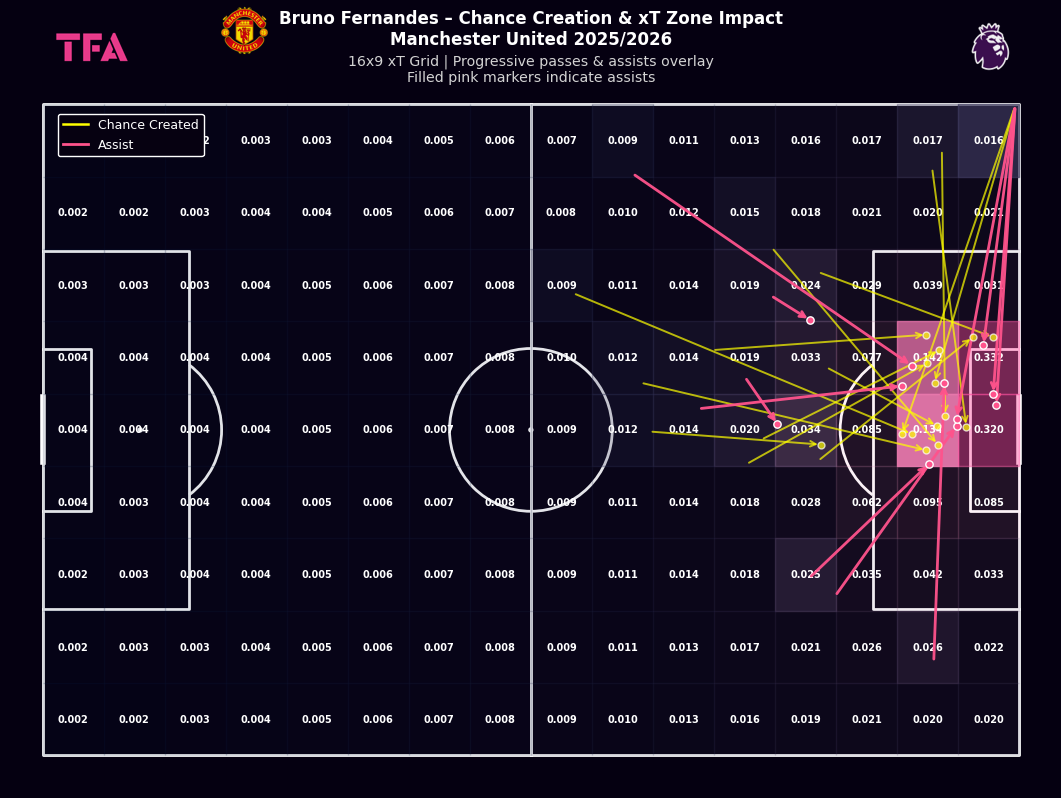

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import Pitch
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.lines import Line2D
from PIL import Image
import os

cols = 16
rows = 9

xT_grid = np.array([
    [0.001,0.002,0.002,0.003,0.003,0.004,0.005,0.006,0.007,0.009,0.011,0.013,0.016,0.017,0.017,0.016],
    [0.002,0.002,0.003,0.004,0.004,0.005,0.006,0.007,0.008,0.010,0.012,0.015,0.018,0.021,0.020,0.021],
    [0.003,0.003,0.003,0.004,0.005,0.006,0.007,0.008,0.009,0.011,0.014,0.019,0.024,0.029,0.039,0.031],
    [0.004,0.004,0.004,0.004,0.005,0.006,0.007,0.008,0.010,0.012,0.014,0.019,0.033,0.077,0.142,0.332],
    [0.004,0.004,0.004,0.004,0.005,0.006,0.007,0.008,0.009,0.012,0.014,0.020,0.034,0.085,0.134,0.320],
    [0.004,0.003,0.004,0.004,0.005,0.006,0.007,0.008,0.009,0.011,0.014,0.018,0.028,0.062,0.095,0.085],
    [0.002,0.003,0.004,0.004,0.005,0.006,0.007,0.008,0.009,0.011,0.014,0.018,0.025,0.035,0.042,0.033],
    [0.002,0.003,0.003,0.004,0.005,0.006,0.007,0.008,0.009,0.011,0.013,0.017,0.021,0.026,0.026,0.022],
    [0.002,0.002,0.003,0.004,0.005,0.006,0.007,0.008,0.009,0.010,0.013,0.016,0.019,0.021,0.020,0.020]
])

df = pd.read_excel(
    r"D:\Work\Data Analysis TFA\51 Excepected threat - xT across PL\6- Bruno Frnandez chances created locations.xlsx"
)

pitch = Pitch(pitch_type='statsbomb', pitch_color='#050011', line_color='white')
fig, ax = pitch.draw(figsize=(12,8))
fig.patch.set_facecolor('#050011')

cmap = LinearSegmentedColormap.from_list("xt_map",
["#0A1C3F","#F5A3C9E0","#E778ACE1","#F05DA2E1","#FF3C97DF","#FF55A4DF"])
norm = Normalize(vmin=xT_grid.min(), vmax=xT_grid.max())

cell_w = 120 / cols
cell_h = 80 / rows

cell_counts = np.zeros((rows, cols))

for _, row in df.iterrows():
    start_col = int(row['x_start'] // cell_w)
    start_row = int(row['y_start'] // cell_h)
    end_col = int(row['x_end'] // cell_w)
    end_row = int(row['y_end'] // cell_h)
    if 0 <= start_row < rows and 0 <= start_col < cols:
        cell_counts[start_row, start_col] += 1
    if 0 <= end_row < rows and 0 <= end_col < cols:
        cell_counts[end_row, end_col] += 1

max_count = cell_counts.max()

for i in range(rows):
    for j in range(cols):
        x = j * cell_w
        y = i * cell_h
        val = xT_grid[i, j]
        color = cmap(norm(val))
        if cell_counts[i, j] > 0:
            alpha_val = 0.2 + (cell_counts[i, j] / max_count) * 0.75
        else:
            alpha_val = 0.12
        rect = plt.Rectangle((x, y), cell_w, cell_h, color=color, alpha=alpha_val)
        ax.add_patch(rect)
        ax.text(x + cell_w/2, y + cell_h/2, f"{val:.3f}",
                ha='center', va='center', color='white', fontsize=7, weight='bold')

for _, row in df.iterrows():
    if row['assist'] == 1:
        ax.annotate('', xy=(row['x_end'], row['y_end']),
                    xytext=(row['x_start'], row['y_start']),
                    arrowprops=dict(arrowstyle='->', color='#FF538C', lw=2, alpha=0.95))
        ax.scatter(row['x_end'], row['y_end'], s=28,
                   color='#FF538C', edgecolor='white', zorder=6)
    else:
        ax.annotate('', xy=(row['x_end'], row['y_end']),
                    xytext=(row['x_start'], row['y_start']),
                    arrowprops=dict(arrowstyle='->', color='yellow', lw=1.4, alpha=0.7))
        ax.scatter(row['x_end'], row['y_end'], s=25,
                   facecolors='yellow', edgecolors='white', alpha=0.7, zorder=6)

plt.suptitle("Bruno Fernandes – Chance Creation & xT Zone Impact\nManchester United 2025/2026",
             color='white', fontsize=12, weight='bold', y=0.992)

fig.text(0.5, 0.902,
         "16x9 xT Grid | Progressive passes & assists overlay\nFilled pink markers indicate assists",
         ha='center', color='lightgrey', fontsize=10.2)

legend_elements = [
    Line2D([0],[0],color='yellow',lw=1.8,label='Chance Created'),
    Line2D([0],[0],color='#FF538C',lw=2,label='Assist'),
]

legend = ax.legend(handles=legend_elements, loc='upper left',
                   fontsize=9, frameon=True,
                   labelcolor='white', bbox_to_anchor=(0.04,0.95))

frame = legend.get_frame()
frame.set_facecolor("#060111")
frame.set_edgecolor("white")
frame.set_alpha(1)

tfa_logo_path = r"D:\Work\Data Analysis TFA\06 How Ancelotti Could Reshape Brazil\logos\TFA.png"
if os.path.exists(tfa_logo_path):
    img = Image.open(tfa_logo_path).convert("RGBA")
    img = img.resize((int(img.width*0.235), int(img.height*0.235)))
    fig.figimage(img, xo=45, yo=704, alpha=0.95, zorder=10)

manu_logo_path = r"D:\Work\Data Analysis TFA\04 Vertical Progressions & Transitional Threat Analysis\logos\Man United.png"
if os.path.exists(manu_logo_path):
    img = Image.open(manu_logo_path).convert("RGBA")
    img = img.resize((int(img.width*0.19), int(img.height*0.19)))
    fig.figimage(img, xo=216, yo=739, alpha=0.95, zorder=10)

epl_logo_path = r"D:\Work\Data Analysis TFA\34 Man City vs Liverpool preview\Main logos\EPL Logo.png"
if os.path.exists(epl_logo_path):
    img = Image.open(epl_logo_path).convert("RGBA")
    img = img.resize((int(img.width*0.8), int(img.height*0.8)))
    fig.figimage(img, xo=965, yo=726, alpha=0.95, zorder=10)

plt.tight_layout()
plt.show()